In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

In [20]:
df = pd.read_csv('C:/Users/Administrator/Documents/projectsML/ML/data/raw/ai4i2020.csv')

# Affichage des 5 premières lignes par defaut
print(df.head())
#les valeurs manquantes
print ("#les valeurs manquantes")
print(df.isnull().sum())



   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

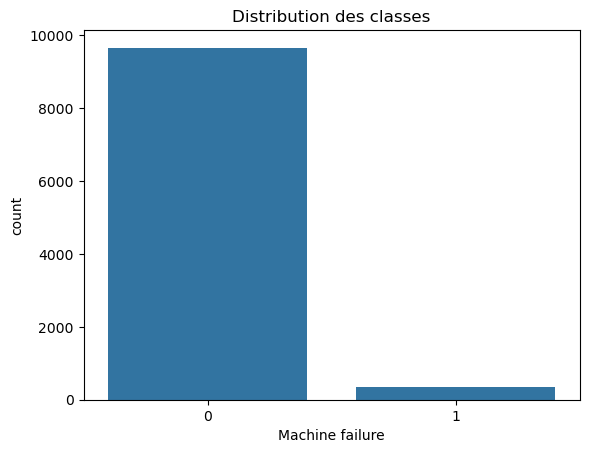

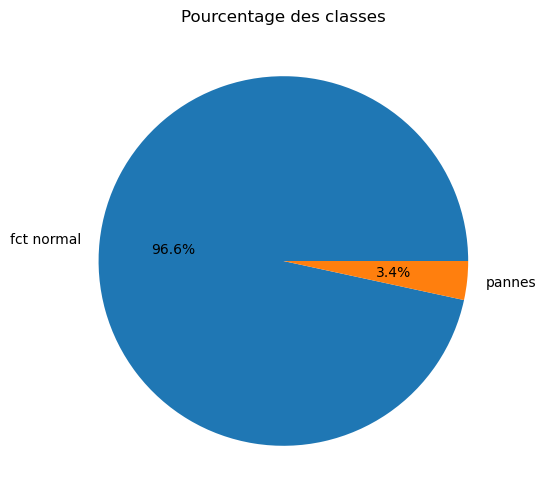

In [21]:
#Visualisation du déséquilibre
sns.countplot(x='Machine failure', data=df)
plt.title('Distribution des classes')

# Percentage calculation
percentages = df['Machine failure'].value_counts(normalize=True) * 100

# Pie chart
plt.figure(figsize=(6,6))

plt.pie(
    percentages,
    labels=['fct normal', 'pannes'],
    autopct='%1.1f%%'
)

plt.title('Pourcentage des classes')
plt.show()

In [22]:
#Suppression des colonnes inutiles
df = df.drop(columns=['UDI', 'Product ID'])
print(df.head())

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


In [23]:
#Encodage de la variable Type
mapping = {
    'L': 0,
    'M': 1,
    'H': 2
}
df['Type'] = df['Type'].map(mapping)

print(df.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


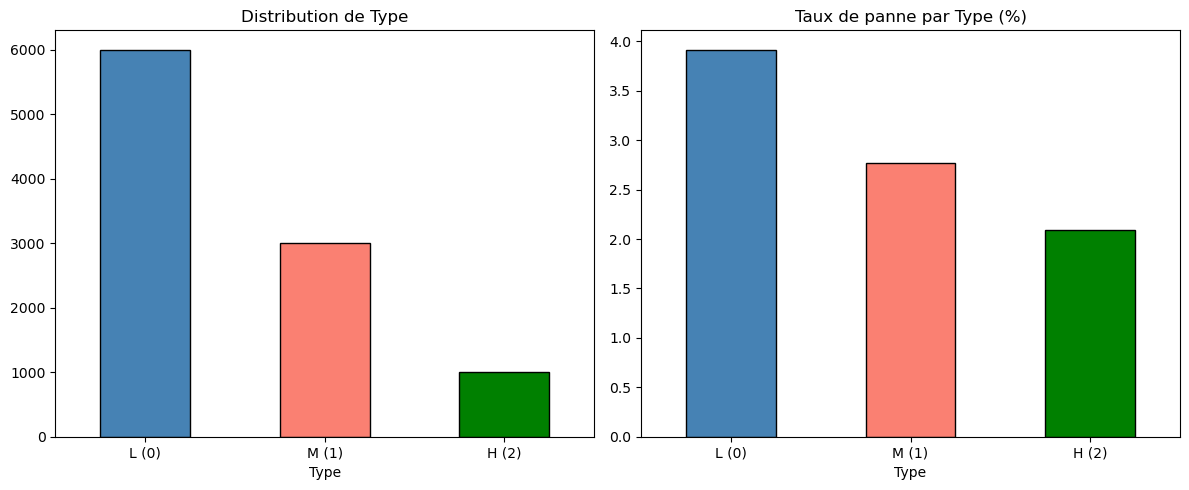

In [24]:
# Visualisation Type après encodage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Type'].value_counts().sort_index().plot(kind='bar', ax=axes[0], 
    color=['steelblue', 'salmon', 'green'], edgecolor='black')
axes[0].set_title('Distribution de Type')
axes[0].set_xticklabels(['L (0)', 'M (1)', 'H (2)'], rotation=0)

(df.groupby('Type')['Machine failure'].mean() * 100).sort_index().plot(
    kind='bar', ax=axes[1], 
    color=['steelblue', 'salmon', 'green'], edgecolor='black')
axes[1].set_title('Taux de panne par Type (%)')
axes[1].set_xticklabels(['L (0)', 'M (1)', 'H (2)'], rotation=0)

plt.tight_layout()
plt.show()

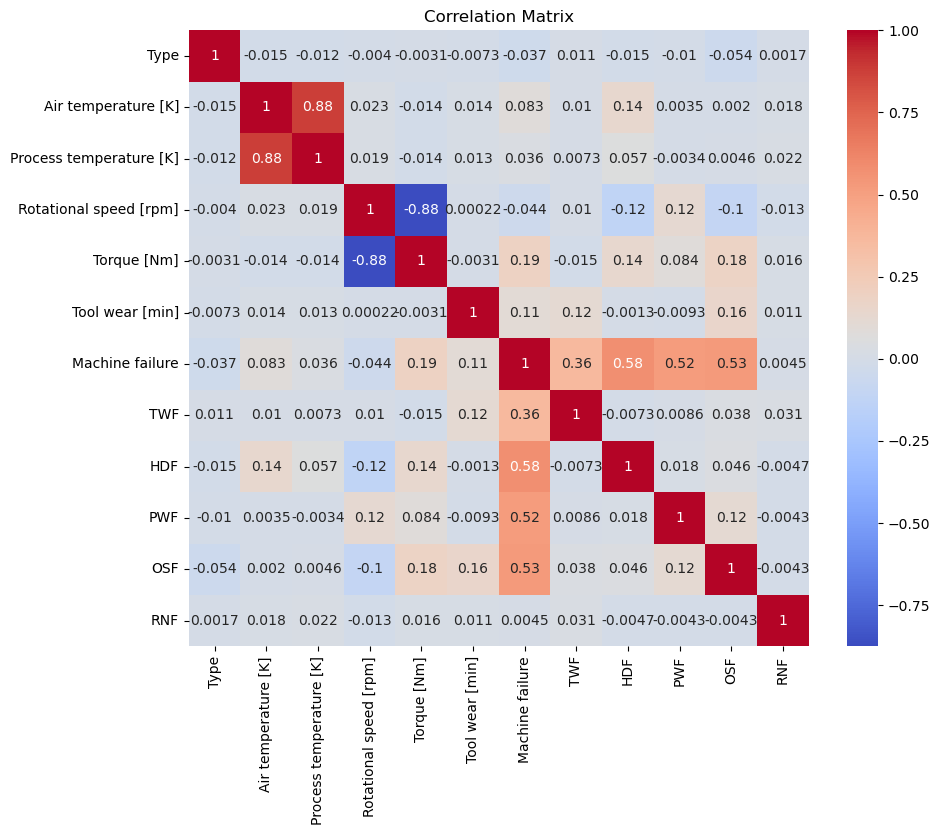

In [25]:
#Matrice de corrélation
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

=== DISTRIBUTION DES SOUS-TYPES DE PANNES ===
TWF: 46 pannes (0.46%)
HDF: 115 pannes (1.15%)
PWF: 95 pannes (0.95%)
OSF: 98 pannes (0.98%)
RNF: 19 pannes (0.19%)


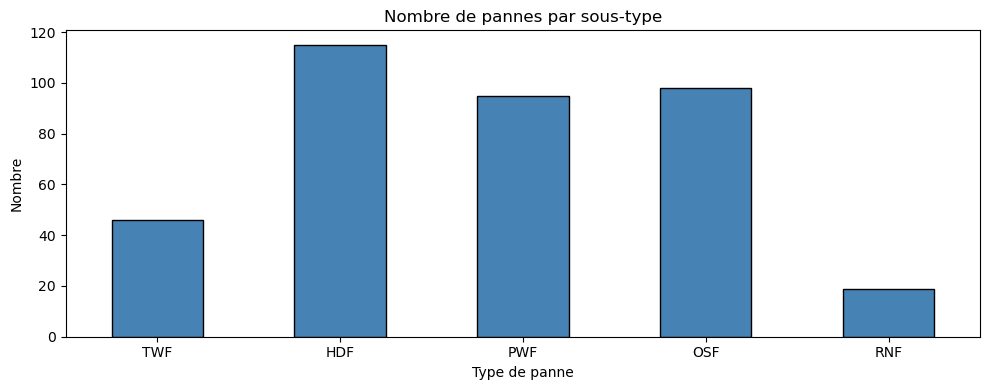

In [26]:
# Analyse des sous-types de pannes
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print("=== DISTRIBUTION DES SOUS-TYPES DE PANNES ===")
for col in failure_cols:
    count = df[col].sum()
    print(f"{col}: {count} pannes ({count/len(df)*100:.2f}%)")

# Visualisation
plt.figure(figsize=(10, 4))
df[failure_cols].sum().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Nombre de pannes par sous-type')
plt.xlabel('Type de panne')
plt.ylabel('Nombre')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [27]:
#Séparation Features / Target
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [28]:
#step1
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
#step2
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [29]:
# normalisation DL
scaler_dl = MinMaxScaler()
X_train_scaled = scaler_dl.fit_transform(X_train)
X_val_scaled   = scaler_dl.transform(X_val)
X_test_scaled  = scaler_dl.transform(X_test)

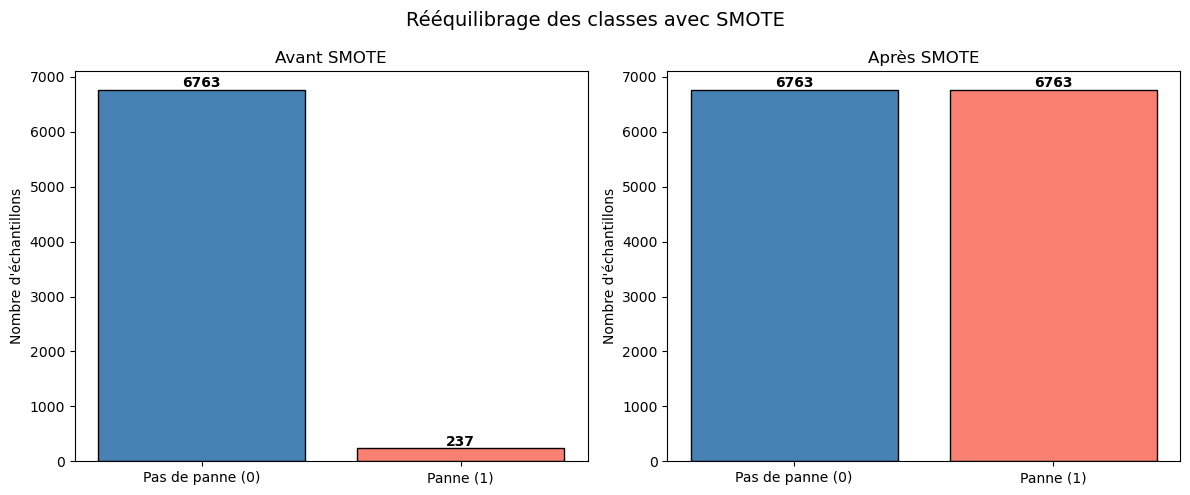

In [30]:
# Visualisation avant / après SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Avant SMOTE
axes[0].bar(['Pas de panne (0)', 'Panne (1)'],
            y_train.value_counts().sort_index(),
            color=['steelblue', 'salmon'],
            edgecolor='black')
axes[0].set_title('Avant SMOTE')
axes[0].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate(y_train.value_counts().sort_index()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Après SMOTE
after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
axes[1].bar(['Pas de panne (0)', 'Panne (1)'],
            after_counts,
            color=['steelblue', 'salmon'],
            edgecolor='black')
axes[1].set_title('Après SMOTE')
axes[1].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Rééquilibrage des classes avec SMOTE', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
#  conversion en Tenseurs PyTorch

X_train_t = torch.FloatTensor(X_train_resampled)
X_val_t   = torch.FloatTensor(X_val_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)

y_train_t = torch.FloatTensor(y_train_resampled).unsqueeze(1)
y_val_t   = torch.FloatTensor(y_val.values).unsqueeze(1)
y_test_t  = torch.FloatTensor(y_test.values).unsqueeze(1)

In [37]:
# Sauvegarde des Tenseurs PyTorch
torch.save(X_train_t, 'C:/Users/Administrator/Documents/projectsML/ML/data/processed_forDL/X_train_dl.pt')
torch.save(X_val_t,   'C:/Users/Administrator/Documents/projectsML/ML/data/processed_forDL/X_val_dl.pt')
torch.save(X_test_t,  'C:/Users/Administrator/Documents/projectsML/ML/data/processed_forDL/X_test_dl.pt')

torch.save(y_train_t, 'C:/Users/Administrator/Documents/projectsML/ML/data/processed_forDL/y_train_dl.pt')
torch.save(y_val_t,   'C:/Users/Administrator/Documents/projectsML/ML/data/processed_forDL/y_val_dl.pt')
torch.save(y_test_t,  'C:/Users/Administrator/Documents/projectsML/ML/data/processed_forDL/y_test_dl.pt')

print("Tenseurs sauvegardés ✅")

Tenseurs sauvegardés ✅


In [33]:
import joblib
joblib.dump(scaler_dl, 'C:/Users/Administrator/Documents/projectsML/ML/models/scaler_dl.pkl')
print("Scaler DL sauvegardé ✅")

Scaler DL sauvegardé ✅


In [34]:
print("Preprocessing DL terminé ✅")
print("\nShapes :")
print("X_train_t :", X_train_t.shape)
print("X_val_t   :", X_val_t.shape)
print("X_test_t  :", X_test_t.shape)

Preprocessing DL terminé ✅

Shapes :
X_train_t : torch.Size([13526, 11])
X_val_t   : torch.Size([1500, 11])
X_test_t  : torch.Size([1500, 11])
